# 10E — Decoupled Box-Supervised Localization Adapter — Seed 42

**Project:** Pedi-CGAM Lite  
**Experiment ID:** `M08_DecoupledLocalizationAdapter_Seed42`  
**Platform:** Kaggle  
**Target GPU:** NVIDIA T4  

## Why this experiment exists

Stages 10A–10D showed a consistent pattern:

- direct box supervision strongly improved localization;
- disease Macro-AUPRC decreased;
- lowering `λbox` and delaying box supervision did not solve the classification drop.

So we stop changing box-loss weights.

## New idea: gradient-isolated localization

The executed **09A / M01** classifier is now protected.

```text
Pediatric X-ray
      ↓
Frozen 09A ResNet50
      ↓
Shared spatial feature map
      ├───────────────────────────────┐
      │                               │
      ↓                               ↓
Frozen disease/finding heads     DETACHED feature map
      │                               │
      │                         Localization adapter
      │                               │
      │                      37 class-specific maps
      │                               │
      │                  Finding loss + box loss
      │                               │
      └──────── classification      lesion evidence
```

The key rule is:

> **Box-loss gradients must never change the 09A backbone, disease head, or finding head.**

Only the small new localization adapter is trainable.

## Scientific question

> Can a gradient-isolated box-supervised branch learn useful lesion localization while preserving the exact 09A disease classifier?

## Frozen base model

- ResNet50
- 320 × 320
- 15 disease outputs
- 37 finding outputs
- executed 09A / M01 checkpoint
- frozen Stage-02 split
- seed 42
- calibration untouched
- official test sealed

## New trainable branch

Localization adapter:

`2048 channels → 256 channels → 37 finding maps`

Loss:

**Localization finding focal loss + 0.10 × box-attention loss**

The adapter receives `feature_maps.detach()`, so its gradients cannot enter the base classifier.

## Main success criteria

1. Base disease predictions remain unchanged from 09A.
2. Frozen-base parameter hash remains unchanged.
3. Localization improves over the 09A no-box CAM baseline.
4. Adapter finding maps remain class-aware through image-level finding supervision.

No CGAM fusion is performed yet.


In [1]:
# ============================================================
# 1. Install DICOM decoders before importing pydicom
# ============================================================
%pip install -q -U "pylibjpeg[all]" pyjpegls

print("✅ DICOM decoder packages ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.3/272.3 kB 15.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
✅ DICOM decoder packages ready.


In [2]:
# ============================================================
# 2. Imports + frozen experiment configuration
# ============================================================
import os
import sys
import gc
import io
import json
import time
import math
import random
import hashlib
import zipfile
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydicom
from pydicom.pixels import apply_modality_lut, apply_voi_lut
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from torchvision.models import resnet50

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    recall_score,
    confusion_matrix,
)

from tqdm.auto import tqdm

EXPERIMENT_ID = "M08_DecoupledLocalizationAdapter_Seed42"
BASELINE_EXPERIMENT_ID = "M01_DiseaseFinding_Multitask_Seed42"

SEED = 42
IMAGE_SIZE = 320
BOX_MASK_SIZE = 80

BATCH_SIZE = 8
NUM_WORKERS = 4

MAX_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 4

LOCALIZATION_LR = 1e-4
LOCALIZATION_WEIGHT_DECAY = 1e-4

FOCAL_GAMMA = 2.0
LOCAL_FINDING_LOSS_WEIGHT = 1.0
BOX_LOSS_WEIGHT = 0.10

FIXED_THRESHOLD = 0.5
USE_AMP = True

EXPECTED_M01_PATHOLOGY14_AUPRC = 0.208471
M01_REPRO_TOLERANCE = 5e-4

EXPECTED_SPLIT_MANIFEST_SHA256 = (
    "3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770"
)

OUTPUT_DIR = Path(f"/kaggle/working/PediCGAM/{EXPERIMENT_ID}")
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
CACHE_DIR = Path(
    f"/kaggle/working/PediCGAM_cache/{EXPERIMENT_ID}_{IMAGE_SIZE}"
)

for d in [OUTPUT_DIR, TABLE_DIR, FIG_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Notebook build: 10E_DECOUPLED_LOCALIZATION_V1")
print("Experiment:", EXPERIMENT_ID)
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("pydicom:", pydicom.__version__)
print("Device:", DEVICE)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "GPU is not active. Enable a Kaggle GPU accelerator before running 10E."
    )

print("GPU:", torch.cuda.get_device_name(0))
print(
    "GPU memory:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB",
)


Notebook build: 10E_DECOUPLED_LOCALIZATION_V1
Experiment: M08_DecoupledLocalizationAdapter_Seed42
Python: 3.12.13
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
pydicom: 3.0.2
Device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB


# 3. Required Kaggle inputs

Attach the same **three inputs** used by 10D:

1. **VinDr-PCXR**
2. **Stage-02 frozen split output**
3. **Executed 09A / M01 output** containing `best_model.pth`

You do **not** need 10A, 10B, 10C, or 10D as inputs.

10E trains only a new localization adapter. The 09A classifier remains frozen.


In [3]:
# ============================================================
# 4. Locate VinDr-PCXR
# ============================================================
KAGGLE_INPUT = Path("/kaggle/input")

def find_vindr_root(search_root=KAGGLE_INPUT):
    candidates = []

    for f in search_root.rglob("image_labels_train.csv"):
        folder = f.parent
        names = {
            p.name
            for p in folder.iterdir()
            if p.is_file()
        }

        score = sum(
            name in names
            for name in [
                "image_labels_train.csv",
                "annotations_train.csv",
            ]
        )

        candidates.append(
            (score, folder)
        )

    candidates.sort(
        key=lambda x: (
            -x[0],
            len(str(x[1])),
        )
    )

    return candidates

vindr_candidates = find_vindr_root()

if not vindr_candidates:
    raise FileNotFoundError(
        "VinDr-PCXR was not found under /kaggle/input."
    )

DATA_ROOT = vindr_candidates[0][1]
TRAIN_DICOM_DIR = DATA_ROOT / "train"

if not TRAIN_DICOM_DIR.exists():
    raise FileNotFoundError(
        f"Training DICOM directory not found: {TRAIN_DICOM_DIR}"
    )

print("VinDr-PCXR root:")
print(DATA_ROOT)
print("\nTraining DICOM directory:")
print(TRAIN_DICOM_DIR)


VinDr-PCXR root:
/kaggle/input/datasets/kalloldaskushol/vindr-pcxr/Pediatric Chest X-ray/physionet.org/files/vindr-pcxr/1.0.0

Training DICOM directory:
/kaggle/input/datasets/kalloldaskushol/vindr-pcxr/Pediatric Chest X-ray/physionet.org/files/vindr-pcxr/1.0.0/train


In [4]:
# ============================================================
# 5. Locate + verify the frozen Stage-02 split
# ============================================================
def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for block in iter(
            lambda: f.read(1024 * 1024),
            b"",
        ):
            h.update(block)

    return h.hexdigest()


def find_frozen_manifest(search_root=KAGGLE_INPUT):
    for p in search_root.rglob(
        "fixed_split_manifest.csv"
    ):
        if (
            sha256_file(p)
            == EXPECTED_SPLIT_MANIFEST_SHA256
        ):
            return p, "direct_csv", None

    for zip_path in search_root.rglob("*.zip"):
        try:
            with zipfile.ZipFile(
                zip_path,
                "r",
            ) as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith(
                        "fixed_split_manifest.csv"
                    )
                ]

                for member in members:
                    raw = zf.read(member)
                    digest = hashlib.sha256(
                        raw
                    ).hexdigest()

                    if (
                        digest
                        == EXPECTED_SPLIT_MANIFEST_SHA256
                    ):
                        temp = Path(
                            "/kaggle/working/"
                            "stage02_manifest_10e.csv"
                        )
                        temp.write_bytes(raw)
                        return (
                            temp,
                            "zip",
                            zip_path,
                        )
        except zipfile.BadZipFile:
            pass

    return None, None, None


MANIFEST_PATH, MANIFEST_SOURCE, MANIFEST_CONTAINER = (
    find_frozen_manifest()
)

if MANIFEST_PATH is None:
    raise FileNotFoundError(
        "Frozen Stage-02 split was not found."
    )

manifest_hash = sha256_file(
    MANIFEST_PATH
)

if (
    manifest_hash
    != EXPECTED_SPLIT_MANIFEST_SHA256
):
    raise RuntimeError(
        "STOP: Stage-02 split SHA-256 mismatch."
    )

print("Manifest:", MANIFEST_PATH)
print("Source:", MANIFEST_SOURCE)
print("SHA-256:", manifest_hash)
print("✅ FROZEN STAGE-02 SPLIT VERIFIED.")


Manifest: /kaggle/input/notebooks/kalloldaskushol/02-fixed-train-validation-calibration-split/PediCGAM/stage02_fixed_split/splits/fixed_split_manifest.csv
Source: direct_csv
SHA-256: 3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770
✅ FROZEN STAGE-02 SPLIT VERIFIED.


In [5]:
# ============================================================
# 6. Locate + verify executed 09A / M01 checkpoint
# ============================================================
M01_EXTRACT_DIR = Path(
    "/kaggle/working/m01_10e_extracted"
)
M01_EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

def checkpoint_matches_m01(path):
    try:
        ckpt = torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )

        return (
            ckpt.get("experiment_id")
            == BASELINE_EXPERIMENT_ID
            and np.isclose(
                float(
                    ckpt.get(
                        "finding_loss_weight"
                    )
                ),
                0.5,
            )
            and ckpt.get("boxes_used")
            is False
            and ckpt.get(
                "split_manifest_sha256"
            )
            == EXPECTED_SPLIT_MANIFEST_SHA256
        )
    except Exception:
        return False


M01_CHECKPOINT_PATH = None
M01_CHECKPOINT_SOURCE = None

for p in KAGGLE_INPUT.rglob(
    "best_model.pth"
):
    if checkpoint_matches_m01(p):
        M01_CHECKPOINT_PATH = p
        M01_CHECKPOINT_SOURCE = "direct"
        break


if M01_CHECKPOINT_PATH is None:
    for zip_path in KAGGLE_INPUT.rglob(
        "*.zip"
    ):
        try:
            with zipfile.ZipFile(
                zip_path,
                "r",
            ) as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith(
                        "/best_model.pth"
                    )
                    or n == "best_model.pth"
                ]

                for member in members:
                    target = (
                        M01_EXTRACT_DIR
                        / "candidate_best_model.pth"
                    )

                    target.write_bytes(
                        zf.read(member)
                    )

                    if checkpoint_matches_m01(
                        target
                    ):
                        M01_CHECKPOINT_PATH = (
                            target
                        )
                        M01_CHECKPOINT_SOURCE = (
                            f"zip:{zip_path.name}"
                        )
                        break

                if (
                    M01_CHECKPOINT_PATH
                    is not None
                ):
                    break

        except zipfile.BadZipFile:
            pass


if M01_CHECKPOINT_PATH is None:
    raise FileNotFoundError(
        "Executed 09A / M01 best_model.pth was not found."
    )

m01_checkpoint = torch.load(
    M01_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

print("✅ 09A / M01 checkpoint verified")
print("Checkpoint:", M01_CHECKPOINT_PATH)
print("Source:", M01_CHECKPOINT_SOURCE)
print(
    "Stored selection metric:",
    m01_checkpoint.get(
        "selection_metric_value"
    ),
)


✅ 09A / M01 checkpoint verified
Checkpoint: /kaggle/input/notebooks/kalloldaskushol/09a-disease-and-finding-multitask-seed42-fixed/PediCGAM/M01_DiseaseFinding_Multitask_Seed42/best_model.pth
Source: direct
Stored selection metric: 0.20847144131991252


In [6]:
# ============================================================
# 7. Load labels + frozen train/validation split
# ============================================================
labels = pd.read_csv(
    DATA_ROOT
    / "image_labels_train.csv"
)

manifest = pd.read_csv(
    MANIFEST_PATH
)

NON_LABEL_COLUMNS = [
    "image_id",
    "rad_ID",
]

LABEL_COLUMNS = [
    c
    for c in labels.columns
    if c not in NON_LABEL_COLUMNS
]

if len(LABEL_COLUMNS) != 15:
    raise RuntimeError(
        f"Expected 15 disease outputs, found {len(LABEL_COLUMNS)}."
    )

if "No finding" not in LABEL_COLUMNS:
    raise RuntimeError(
        "Disease labels do not contain 'No finding'."
    )

PATHOLOGY_COLUMNS = [
    c
    for c in LABEL_COLUMNS
    if c != "No finding"
]

df = manifest.merge(
    labels,
    on="image_id",
    how="left",
    validate="one_to_one",
)

if df[LABEL_COLUMNS].isna().any().any():
    raise RuntimeError(
        "Some split-manifest images have missing disease labels."
    )

split_counts = df[
    "split"
].value_counts()

if int(split_counts["train"]) != 5408:
    raise RuntimeError(
        "Frozen train count is not 5,408."
    )

if int(split_counts["validation"]) != 1159:
    raise RuntimeError(
        "Frozen validation count is not 1,159."
    )

if int(split_counts["calibration"]) != 1161:
    raise RuntimeError(
        "Frozen calibration count is not 1,161."
    )

train_df = (
    df[df["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

val_df = (
    df[df["split"] == "validation"]
    .copy()
    .reset_index(drop=True)
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print(
    "Calibration images NOT used:",
    int(split_counts["calibration"]),
)


Training images: 5408
Validation images: 1159
Calibration images NOT used: 1161


In [7]:
# ============================================================
# 8. Build 37 image-level finding targets from class_name
# ============================================================
annotations = pd.read_csv(
    DATA_ROOT
    / "annotations_train.csv"
)

required_annotation_columns = {
    "image_id",
    "class_name",
    "x_min",
    "y_min",
    "x_max",
    "y_max",
}

missing_cols = (
    required_annotation_columns
    - set(annotations.columns)
)

if missing_cols:
    raise RuntimeError(
        "annotations_train.csv is missing: "
        + str(sorted(missing_cols))
    )

annotation_class_names = (
    annotations["class_name"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

FINDING_CLASSES = (
    ["No finding"]
    + sorted(
        x
        for x in annotation_class_names
        if x != "No finding"
    )
)

if len(FINDING_CLASSES) != 37:
    raise RuntimeError(
        f"Expected 37 finding outputs, found {len(FINDING_CLASSES)}."
    )

NO_FINDING_INDEX = (
    FINDING_CLASSES.index(
        "No finding"
    )
)

FINDING_TARGET_COLUMNS = [
    f"finding_target_{i:02d}"
    for i in range(
        len(FINDING_CLASSES)
    )
]

finding_matrix = pd.crosstab(
    annotations[
        "image_id"
    ].astype(str),
    annotations[
        "class_name"
    ].astype(str),
)

finding_matrix = (
    finding_matrix
    .reindex(
        columns=FINDING_CLASSES,
        fill_value=0,
    )
    .clip(upper=1)
    .astype(np.float32)
)

df["image_id_str"] = (
    df["image_id"]
    .astype(str)
)

for target_col, class_name in zip(
    FINDING_TARGET_COLUMNS,
    FINDING_CLASSES,
):
    df[target_col] = (
        df["image_id_str"]
        .map(
            finding_matrix[
                class_name
            ]
        )
        .fillna(0)
        .astype(np.float32)
    )

train_df = (
    df[df["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

val_df = (
    df[df["split"] == "validation"]
    .copy()
    .reset_index(drop=True)
)

finding_class_map = pd.DataFrame({
    "finding_index":
        range(
            len(FINDING_CLASSES)
        ),
    "class_name":
        FINDING_CLASSES,
})

finding_class_map.to_csv(
    TABLE_DIR
    / "finding_class_map.csv",
    index=False,
)

print("Finding outputs:", len(FINDING_CLASSES))
print("Actual local findings:", len(FINDING_CLASSES) - 1)
print("Numeric class_id used: NO")


Finding outputs: 37
Actual local findings: 36
Numeric class_id used: NO


In [8]:
# ============================================================
# 9. Build DICOM index
# ============================================================
dicom_paths = {
    p.stem: p
    for p in TRAIN_DICOM_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower()
    in {".dicom", ".dcm"}
}

required_ids = (
    set(
        train_df[
            "image_id"
        ].astype(str)
    )
    | set(
        val_df[
            "image_id"
        ].astype(str)
    )
)

missing_files = sorted(
    required_ids
    - set(dicom_paths.keys())
)

print(
    "DICOM files indexed:",
    len(dicom_paths),
)
print(
    "Train+validation IDs required:",
    len(required_ids),
)
print("Missing files:", len(missing_files))

if missing_files:
    raise FileNotFoundError(
        "Some frozen train/validation DICOM files are missing."
    )

print("✅ All train/validation DICOM files are present.")


DICOM files indexed: 7728
Train+validation IDs required: 6567
Missing files: 0
✅ All train/validation DICOM files are present.


In [9]:
# ============================================================
# 10. Prepare normalized valid bounding boxes
# ============================================================
BOX_COLS = [
    "x_min",
    "y_min",
    "x_max",
    "y_max",
]

box_numeric = annotations[
    BOX_COLS
].apply(
    pd.to_numeric,
    errors="coerce",
)

valid_box_flag = (
    box_numeric.notna().all(axis=1)
    & (
        box_numeric["x_max"]
        > box_numeric["x_min"]
    )
    & (
        box_numeric["y_max"]
        > box_numeric["y_min"]
    )
    & (
        box_numeric[BOX_COLS]
        >= 0
    ).all(axis=1)
)

valid_boxes = annotations.loc[
    valid_box_flag
].copy()

for c in BOX_COLS:
    valid_boxes[c] = (
        box_numeric.loc[
            valid_box_flag,
            c,
        ].astype(float)
    )

valid_boxes = valid_boxes[
    valid_boxes[
        "class_name"
    ].astype(str)
    != "No finding"
].copy()

valid_boxes["image_id"] = (
    valid_boxes[
        "image_id"
    ].astype(str)
)

valid_boxes = valid_boxes[
    valid_boxes[
        "image_id"
    ].isin(required_ids)
].copy()

boxed_ids = sorted(
    valid_boxes[
        "image_id"
    ].unique().tolist()
)

dimension_rows = []

for image_id in tqdm(
    boxed_ids,
    desc="Reading boxed-image dimensions",
):
    ds = pydicom.dcmread(
        str(
            dicom_paths[
                image_id
            ]
        ),
        stop_before_pixels=True,
        specific_tags=[
            "Rows",
            "Columns",
        ],
    )

    dimension_rows.append({
        "image_id": image_id,
        "rows": int(ds.Rows),
        "columns": int(ds.Columns),
    })

dimensions_df = pd.DataFrame(
    dimension_rows
)

valid_boxes = valid_boxes.merge(
    dimensions_df,
    on="image_id",
    how="left",
    validate="many_to_one",
)

valid_boxes["nx_min"] = (
    valid_boxes["x_min"]
    / valid_boxes["columns"]
).clip(0, 1)

valid_boxes["nx_max"] = (
    valid_boxes["x_max"]
    / valid_boxes["columns"]
).clip(0, 1)

valid_boxes["ny_min"] = (
    valid_boxes["y_min"]
    / valid_boxes["rows"]
).clip(0, 1)

valid_boxes["ny_max"] = (
    valid_boxes["y_max"]
    / valid_boxes["rows"]
).clip(0, 1)

post_clip_valid = (
    (
        valid_boxes["nx_max"]
        > valid_boxes["nx_min"]
    )
    & (
        valid_boxes["ny_max"]
        > valid_boxes["ny_min"]
    )
)

if not post_clip_valid.all():
    raise RuntimeError(
        "At least one box became invalid after normalization/clipping."
    )

finding_to_index = {
    name: i
    for i, name in enumerate(
        FINDING_CLASSES
    )
}

BOXES_BY_IMAGE = {}

for image_id, group in valid_boxes.groupby(
    "image_id"
):
    items = []

    for row in group.itertuples(
        index=False
    ):
        items.append((
            finding_to_index[
                str(row.class_name)
            ],
            float(row.nx_min),
            float(row.ny_min),
            float(row.nx_max),
            float(row.ny_max),
        ))

    BOXES_BY_IMAGE[
        str(image_id)
    ] = items

train_boxed_images = int(
    train_df[
        "image_id"
    ].astype(str)
    .isin(BOXES_BY_IMAGE)
    .sum()
)

val_boxed_images = int(
    val_df[
        "image_id"
    ].astype(str)
    .isin(BOXES_BY_IMAGE)
    .sum()
)

box_summary = pd.DataFrame([
    {
        "metric":
            "valid_box_rows_train_validation",
        "value":
            int(len(valid_boxes)),
    },
    {
        "metric":
            "unique_boxed_images_train_validation",
        "value":
            int(len(BOXES_BY_IMAGE)),
    },
    {
        "metric":
            "boxed_train_images",
        "value":
            train_boxed_images,
    },
    {
        "metric":
            "boxed_validation_images",
        "value":
            val_boxed_images,
    },
])

box_summary.to_csv(
    TABLE_DIR
    / "box_annotation_summary.csv",
    index=False,
)

display(box_summary)
print("✅ Box metadata prepared.")


Reading boxed-image dimensions:   0%|          | 0/2195 [00:00<?, ?it/s]

,metric,value
0,valid_box_rows_train_validation,4433
1,unique_boxed_images_train_validation,2195
2,boxed_train_images,1808
3,boxed_validation_images,387


✅ Box metadata prepared.


In [10]:
# ============================================================
# 11. Frozen pathology head/middle/tail groups
# ============================================================
def load_stage02_csv(filename):
    matches = list(
        KAGGLE_INPUT.rglob(
            filename
        )
    )

    if matches:
        return pd.read_csv(
            matches[0]
        )

    for zip_path in KAGGLE_INPUT.rglob(
        "*.zip"
    ):
        try:
            with zipfile.ZipFile(
                zip_path,
                "r",
            ) as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith(
                        filename
                    )
                ]

                if members:
                    return pd.read_csv(
                        io.BytesIO(
                            zf.read(
                                members[0]
                            )
                        )
                    )
        except zipfile.BadZipFile:
            pass

    return None


rarity_groups = load_stage02_csv(
    "frozen_pathology_head_middle_tail_groups.csv"
)

if rarity_groups is None:
    raise FileNotFoundError(
        "Frozen pathology rarity groups were not found."
    )

rarity_groups = rarity_groups[
    [
        "label",
        "positive_images",
        "frequency_rank",
        "rarity_group",
    ]
].copy()

if (
    set(
        rarity_groups[
            "label"
        ]
    )
    != set(PATHOLOGY_COLUMNS)
):
    raise RuntimeError(
        "Frozen pathology groups do not match the 14 pathology labels."
    )

GROUP_TO_LABELS = {
    group:
        rarity_groups.loc[
            rarity_groups[
                "rarity_group"
            ] == group,
            "label",
        ].tolist()
    for group in [
        "Head",
        "Middle",
        "Tail",
    ]
}

display(rarity_groups)


,label,positive_images,frequency_rank,rarity_group
0,Bronchitis,842,1,Head
1,Brocho-pneumonia,545,2,Head
2,Bronchiolitis,497,3,Head
3,Other disease,412,4,Head
4,Pneumonia,392,5,Head
5,Hyaline membrane disease,19,6,Middle
6,Tuberculosis,14,7,Middle
7,Situs inversus,11,8,Middle
8,Mediastinal tumor,8,9,Middle
9,Pleuro-pneumonia,6,10,Middle


In [11]:
# ============================================================
# 12. DICOM preprocessing + cache
# ============================================================
def dicom_to_uint8_320(
    path,
    output_size=IMAGE_SIZE,
):
    ds = pydicom.dcmread(
        str(path)
    )

    arr = ds.pixel_array

    try:
        arr = apply_modality_lut(
            arr,
            ds,
        )
    except Exception:
        arr = np.asarray(arr)

    try:
        arr = apply_voi_lut(
            arr,
            ds,
        )
    except Exception:
        arr = np.asarray(arr)

    arr = np.asarray(
        arr,
        dtype=np.float32,
    )

    if not np.isfinite(arr).all():
        finite = arr[
            np.isfinite(arr)
        ]

        fill = (
            float(
                np.median(
                    finite
                )
            )
            if finite.size
            else 0.0
        )

        arr = np.nan_to_num(
            arr,
            nan=fill,
            posinf=fill,
            neginf=fill,
        )

    if (
        str(
            getattr(
                ds,
                "PhotometricInterpretation",
                "",
            )
        ).upper()
        == "MONOCHROME1"
    ):
        arr = (
            arr.max()
            + arr.min()
            - arr
        )

    lo, hi = np.percentile(
        arr,
        [0.5, 99.5],
    )

    if (
        not np.isfinite(lo)
        or not np.isfinite(hi)
        or hi <= lo
    ):
        lo = float(arr.min())
        hi = float(arr.max())

    if hi > lo:
        arr = np.clip(
            arr,
            lo,
            hi,
        )
        arr = (
            arr - lo
        ) / (
            hi - lo
        )
    else:
        arr = np.zeros_like(
            arr,
            dtype=np.float32,
        )

    arr = (
        arr * 255.0
    ).round().astype(
        np.uint8
    )

    image = Image.fromarray(
        arr
    )

    image = image.resize(
        (
            output_size,
            output_size,
        ),
        resample=Image.Resampling.BILINEAR,
    )

    return np.asarray(
        image,
        dtype=np.uint8,
    )


def cache_images(
    dataframe,
    split_name,
):
    split_cache = (
        CACHE_DIR
        / split_name
    )

    split_cache.mkdir(
        parents=True,
        exist_ok=True,
    )

    failures = []

    for image_id in tqdm(
        dataframe[
            "image_id"
        ].astype(str).tolist(),
        desc=f"Caching {split_name}",
    ):
        target = (
            split_cache
            / f"{image_id}.npy"
        )

        if target.exists():
            continue

        try:
            arr = dicom_to_uint8_320(
                dicom_paths[
                    image_id
                ]
            )

            np.save(
                target,
                arr,
                allow_pickle=False,
            )

        except Exception as e:
            failures.append({
                "split":
                    split_name,
                "image_id":
                    image_id,
                "error":
                    f"{type(e).__name__}: {e}",
            })

    return pd.DataFrame(
        failures
    )


train_cache_fail = cache_images(
    train_df,
    "train",
)

val_cache_fail = cache_images(
    val_df,
    "validation",
)

cache_failures = pd.concat(
    [
        train_cache_fail,
        val_cache_fail,
    ],
    ignore_index=True,
)

cache_failures.to_csv(
    TABLE_DIR
    / "preprocessing_cache_failures.csv",
    index=False,
)

print(
    "Preprocessing failures:",
    len(cache_failures),
)

if len(cache_failures):
    raise RuntimeError(
        "Preprocessing failed for at least one image."
    )

print("✅ Train/validation caches are complete.")


Caching train:   0%|          | 0/5408 [00:00<?, ?it/s]

Caching validation:   0%|          | 0/1159 [00:00<?, ?it/s]

Preprocessing failures: 0
✅ Train/validation caches are complete.


# 13. Joint image + box-mask transform

The normalization is intentionally kept identical to the executed Stage-09/10 notebooks so 10E remains comparable.

No horizontal or vertical flips are used.


In [12]:
# ============================================================
# 14. Dataset + joint transforms
# ============================================================
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

# Intentionally preserved from the executed previous notebooks.
IMAGENET_STD = [
    0.229,
    0.320,
    0.225,
]

color_jitter = transforms.ColorJitter(
    brightness=0.10,
    contrast=0.10,
)


def rasterize_box_masks(
    image_id,
):
    masks = torch.zeros(
        (
            len(FINDING_CLASSES),
            BOX_MASK_SIZE,
            BOX_MASK_SIZE,
        ),
        dtype=torch.uint8,
    )

    for (
        class_index,
        nx_min,
        ny_min,
        nx_max,
        ny_max,
    ) in BOXES_BY_IMAGE.get(
        str(image_id),
        [],
    ):
        x1 = int(
            np.floor(
                nx_min
                * BOX_MASK_SIZE
            )
        )
        y1 = int(
            np.floor(
                ny_min
                * BOX_MASK_SIZE
            )
        )
        x2 = int(
            np.ceil(
                nx_max
                * BOX_MASK_SIZE
            )
        )
        y2 = int(
            np.ceil(
                ny_max
                * BOX_MASK_SIZE
            )
        )

        x1 = int(
            np.clip(
                x1,
                0,
                BOX_MASK_SIZE - 1,
            )
        )
        y1 = int(
            np.clip(
                y1,
                0,
                BOX_MASK_SIZE - 1,
            )
        )
        x2 = int(
            np.clip(
                x2,
                x1 + 1,
                BOX_MASK_SIZE,
            )
        )
        y2 = int(
            np.clip(
                y2,
                y1 + 1,
                BOX_MASK_SIZE,
            )
        )

        masks[
            class_index,
            y1:y2,
            x1:x2,
        ] = 1

    return masks


class JointTrainTransform:
    def __call__(
        self,
        image,
        box_masks,
    ):
        (
            angle,
            translate,
            scale,
            shear,
        ) = transforms.RandomAffine.get_params(
            degrees=[
                -5.0,
                5.0,
            ],
            translate=[
                0.03,
                0.03,
            ],
            scale_ranges=[
                0.95,
                1.05,
            ],
            shears=None,
            img_size=[
                IMAGE_SIZE,
                IMAGE_SIZE,
            ],
        )

        image = TF.affine(
            image,
            angle=angle,
            translate=translate,
            scale=scale,
            shear=shear,
            interpolation=InterpolationMode.NEAREST,
            fill=0,
        )

        mask_translate = [
            int(
                round(
                    translate[0]
                    * BOX_MASK_SIZE
                    / IMAGE_SIZE
                )
            ),
            int(
                round(
                    translate[1]
                    * BOX_MASK_SIZE
                    / IMAGE_SIZE
                )
            ),
        ]

        box_masks = TF.affine(
            box_masks.float(),
            angle=angle,
            translate=mask_translate,
            scale=scale,
            shear=shear,
            interpolation=InterpolationMode.NEAREST,
            fill=0,
        )

        box_masks = (
            box_masks > 0.5
        ).to(torch.uint8)

        image = color_jitter(
            image
        )

        image = TF.normalize(
            image,
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        )

        return image, box_masks


class JointValidationTransform:
    def __call__(
        self,
        image,
        box_masks,
    ):
        image = TF.normalize(
            image,
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        )

        return image, box_masks


class CachedCXRLocalizationDataset(
    Dataset
):
    def __init__(
        self,
        dataframe,
        split_name,
        cache_root,
        disease_label_columns,
        finding_target_columns,
        transform=None,
    ):
        self.df = (
            dataframe
            .reset_index(drop=True)
        )
        self.split_name = split_name
        self.cache_dir = (
            Path(cache_root)
            / split_name
        )
        self.disease_label_columns = (
            disease_label_columns
        )
        self.finding_target_columns = (
            finding_target_columns
        )
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(
        self,
        idx,
    ):
        row = self.df.iloc[idx]
        image_id = str(
            row["image_id"]
        )

        arr = np.load(
            self.cache_dir
            / f"{image_id}.npy",
            allow_pickle=False,
        )

        image = (
            torch.from_numpy(
                arr
            )
            .float()
            .unsqueeze(0)
            / 255.0
        )

        image = image.repeat(
            3,
            1,
            1,
        )

        disease_y = torch.tensor(
            row[
                self.disease_label_columns
            ].to_numpy(
                dtype=np.float32
            ),
            dtype=torch.float32,
        )

        finding_y = torch.tensor(
            row[
                self.finding_target_columns
            ].to_numpy(
                dtype=np.float32
            ),
            dtype=torch.float32,
        )

        box_masks = rasterize_box_masks(
            image_id
        )

        if self.transform is not None:
            (
                image,
                box_masks,
            ) = self.transform(
                image,
                box_masks,
            )

        box_present = (
            box_masks
            .flatten(1)
            .any(dim=1)
        )

        box_present[
            NO_FINDING_INDEX
        ] = False

        return (
            image,
            disease_y,
            finding_y,
            box_masks,
            box_present,
            image_id,
        )


train_dataset = (
    CachedCXRLocalizationDataset(
        train_df,
        "train",
        CACHE_DIR,
        LABEL_COLUMNS,
        FINDING_TARGET_COLUMNS,
        transform=JointTrainTransform(),
    )
)

val_dataset = (
    CachedCXRLocalizationDataset(
        val_df,
        "validation",
        CACHE_DIR,
        LABEL_COLUMNS,
        FINDING_TARGET_COLUMNS,
        transform=JointValidationTransform(),
    )
)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
    generator=generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
)

sample_batch = next(
    iter(train_loader)
)

print(
    "Image batch:",
    sample_batch[0].shape,
)
print(
    "Disease targets:",
    sample_batch[1].shape,
)
print(
    "Finding targets:",
    sample_batch[2].shape,
)
print(
    "Box masks:",
    sample_batch[3].shape,
)
print(
    "Box-present flags:",
    sample_batch[4].shape,
)

bad_box_targets = (
    sample_batch[4].bool()
    & (
        sample_batch[2]
        <= 0.5
    )
)

if bad_box_targets.any():
    raise RuntimeError(
        "A box-supervised pair is not positive in the finding target."
    )

print("✅ Dataset alignment checks PASS.")


Image batch: torch.Size([8, 3, 320, 320])
Disease targets: torch.Size([8, 15])
Finding targets: torch.Size([8, 37])
Box masks: torch.Size([8, 37, 80, 80])
Box-present flags: torch.Size([8, 37])
✅ Dataset alignment checks PASS.


In [13]:
# ============================================================
# 15. Frozen 09A base + trainable decoupled localization adapter
# ============================================================
class FrozenM01Base(nn.Module):
    def __init__(
        self,
        n_disease_labels,
        n_finding_labels,
    ):
        super().__init__()

        self.backbone = resnet50(
            weights=None
        )

        feature_dim = (
            self.backbone
            .fc
            .in_features
        )

        self.backbone.fc = (
            nn.Identity()
        )

        self.disease_head = nn.Linear(
            feature_dim,
            n_disease_labels,
        )

        self.finding_head = nn.Linear(
            feature_dim,
            n_finding_labels,
        )

    def extract_spatial_features(
        self,
        x,
    ):
        b = self.backbone

        x = b.conv1(x)
        x = b.bn1(x)
        x = b.relu(x)
        x = b.maxpool(x)

        x = b.layer1(x)
        x = b.layer2(x)
        x = b.layer3(x)
        x = b.layer4(x)

        return x

    def forward(
        self,
        x,
    ):
        feature_maps = (
            self.extract_spatial_features(
                x
            )
        )

        pooled = (
            self.backbone
            .avgpool(
                feature_maps
            )
        )

        pooled = torch.flatten(
            pooled,
            1,
        )

        disease_logits = (
            self.disease_head(
                pooled
            )
        )

        finding_logits = (
            self.finding_head(
                pooled
            )
        )

        return (
            disease_logits,
            finding_logits,
            feature_maps,
        )


class LocalizationAdapter(nn.Module):
    def __init__(
        self,
        in_channels=2048,
        hidden_channels=256,
        n_findings=37,
    ):
        super().__init__()

        self.reduce = nn.Conv2d(
            in_channels,
            hidden_channels,
            kernel_size=1,
            bias=False,
        )

        self.norm = nn.GroupNorm(
            num_groups=32,
            num_channels=hidden_channels,
        )

        self.activation = nn.ReLU(
            inplace=True
        )

        self.class_maps = nn.Conv2d(
            hidden_channels,
            n_findings,
            kernel_size=1,
            bias=True,
        )

    def forward(
        self,
        detached_feature_maps,
    ):
        x = self.reduce(
            detached_feature_maps
        )
        x = self.norm(x)
        x = self.activation(x)

        class_maps = (
            self.class_maps(x)
        )

        local_finding_logits = (
            F.adaptive_avg_pool2d(
                class_maps,
                output_size=1,
            )
            .flatten(1)
        )

        return (
            local_finding_logits,
            class_maps,
        )


base_model = FrozenM01Base(
    n_disease_labels=
        len(LABEL_COLUMNS),
    n_finding_labels=
        len(FINDING_CLASSES),
).to(DEVICE)

load_result = (
    base_model.load_state_dict(
        m01_checkpoint[
            "model_state_dict"
        ],
        strict=True,
    )
)

print(
    "09A checkpoint load:",
    load_result,
)

# Freeze EVERY base parameter.
for parameter in (
    base_model.parameters()
):
    parameter.requires_grad = False

base_model.eval()

localization_adapter = (
    LocalizationAdapter(
        in_channels=2048,
        hidden_channels=256,
        n_findings=
            len(FINDING_CLASSES),
    )
    .to(DEVICE)
)

base_trainable = sum(
    p.numel()
    for p in base_model.parameters()
    if p.requires_grad
)

adapter_trainable = sum(
    p.numel()
    for p in localization_adapter.parameters()
    if p.requires_grad
)

print(
    "Trainable base parameters:",
    base_trainable,
)
print(
    "Trainable adapter parameters:",
    f"{adapter_trainable:,}",
)

if base_trainable != 0:
    raise RuntimeError(
        "STOP: base 09A model is not fully frozen."
    )

print("✅ Frozen base + trainable localization adapter ready.")


09A checkpoint load: <All keys matched successfully>
Trainable base parameters: 0
Trainable adapter parameters: 534,309
✅ Frozen base + trainable localization adapter ready.


In [14]:
# ============================================================
# 16. Parameter-state hash for frozen-base integrity
# ============================================================
def hash_model_state(
    model,
):
    h = hashlib.sha256()

    for name, tensor in sorted(
        model.state_dict().items()
    ):
        h.update(
            name.encode(
                "utf-8"
            )
        )

        arr = (
            tensor.detach()
            .cpu()
            .contiguous()
            .numpy()
        )

        h.update(
            arr.tobytes()
        )

    return h.hexdigest()


FROZEN_BASE_HASH_BEFORE = (
    hash_model_state(
        base_model
    )
)

print(
    "Frozen base SHA-256 before adapter training:"
)
print(
    FROZEN_BASE_HASH_BEFORE
)


Frozen base SHA-256 before adapter training:
14c0150f36892f573c19dd1d3d2d221af69ab3c7ef092523af84c357b8cc5ec0


In [15]:
# ============================================================
# 17. Losses + attention/localization helpers
# ============================================================
class BinaryFocalLoss(nn.Module):
    def __init__(
        self,
        gamma=2.0,
        reduction="mean",
    ):
        super().__init__()
        self.gamma = float(gamma)
        self.reduction = reduction

    def forward(
        self,
        logits,
        targets,
    ):
        bce = (
            F.binary_cross_entropy_with_logits(
                logits,
                targets,
                reduction="none",
            )
        )

        probs = torch.sigmoid(
            logits
        )

        p_t = (
            probs * targets
            + (
                1.0 - probs
            )
            * (
                1.0 - targets
            )
        )

        focal_factor = (
            1.0 - p_t
        ).pow(
            self.gamma
        )

        loss = (
            focal_factor
            * bce
        )

        if (
            self.reduction
            == "mean"
        ):
            return loss.mean()

        if (
            self.reduction
            == "sum"
        ):
            return loss.sum()

        return loss


def maps_to_attention(
    class_maps,
):
    b, k, h, w = (
        class_maps.shape
    )

    return torch.softmax(
        class_maps.flatten(2),
        dim=-1,
    ).view(
        b,
        k,
        h,
        w,
    )


def localization_stats_from_maps(
    class_maps,
    finding_targets,
    box_masks,
    box_present,
    eps=1e-6,
):
    attention = maps_to_attention(
        class_maps
    )

    h, w = (
        attention.shape[-2:]
    )

    target_masks = (
        F.adaptive_max_pool2d(
            box_masks.float(),
            output_size=(
                h,
                w,
            ),
        )
        > 0
    ).float()

    valid = (
        box_present.bool()
        & (
            finding_targets
            > 0.5
        )
    )

    valid[
        :,
        NO_FINDING_INDEX,
    ] = False

    attention_mass = (
        attention
        * target_masks
    ).sum(
        dim=(-2, -1)
    )

    valid_count = int(
        valid.sum()
        .detach()
        .cpu()
    )

    if valid_count:
        selected_mass = (
            attention_mass[
                valid
            ]
            .clamp(
                min=eps,
                max=1.0,
            )
        )

        box_loss = (
            -torch.log(
                selected_mass
            ).mean()
        )
    else:
        box_loss = (
            class_maps.sum()
            * 0.0
        )

    flat_attention = (
        attention.flatten(2)
    )

    flat_masks = (
        target_masks.flatten(2)
    )

    max_indices = (
        flat_attention.argmax(
            dim=-1,
            keepdim=True,
        )
    )

    pointing_hit = (
        flat_masks.gather(
            dim=2,
            index=max_indices,
        )
        .squeeze(-1)
    )

    box_area_fraction = (
        target_masks.mean(
            dim=(-2, -1)
        )
    )

    return {
        "loss":
            box_loss,
        "valid":
            valid,
        "attention_mass":
            attention_mass,
        "pointing_hit":
            pointing_hit,
        "box_area_fraction":
            box_area_fraction,
    }


finding_criterion = (
    BinaryFocalLoss(
        gamma=FOCAL_GAMMA,
    )
)

print("✅ Loss and localization helpers ready.")


✅ Loss and localization helpers ready.


In [16]:
# ============================================================
# 18. Classification + finding metric helpers
# ============================================================
def safe_average_precision(
    y_true,
    y_prob,
):
    if (
        np.unique(
            y_true
        ).size < 2
        and y_true.sum() == 0
    ):
        return np.nan

    try:
        return average_precision_score(
            y_true,
            y_prob,
        )
    except Exception:
        return np.nan


def safe_auroc(
    y_true,
    y_prob,
):
    if (
        np.unique(
            y_true
        ).size < 2
    ):
        return np.nan

    try:
        return roc_auc_score(
            y_true,
            y_prob,
        )
    except Exception:
        return np.nan


def binary_specificity(
    y_true,
    y_pred,
):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    tn, fp, fn, tp = (
        cm.ravel()
    )

    return (
        tn / (tn + fp)
        if (
            tn + fp
        ) > 0
        else np.nan
    )


def compute_disease_metrics(
    y_true,
    y_prob,
):
    y_pred = (
        y_prob
        >= FIXED_THRESHOLD
    ).astype(int)

    rows = []

    for i, label in enumerate(
        LABEL_COLUMNS
    ):
        yt = (
            y_true[:, i]
            .astype(int)
        )

        yp = y_prob[:, i]
        yh = y_pred[:, i]

        rows.append({
            "label":
                label,
            "positive_validation_images":
                int(yt.sum()),
            "AUPRC":
                safe_average_precision(
                    yt,
                    yp,
                ),
            "AUROC":
                safe_auroc(
                    yt,
                    yp,
                ),
            "F1_at_0.5":
                f1_score(
                    yt,
                    yh,
                    zero_division=0,
                ),
            "Sensitivity_at_0.5":
                recall_score(
                    yt,
                    yh,
                    zero_division=0,
                ),
            "Specificity_at_0.5":
                binary_specificity(
                    yt,
                    yh,
                ),
        })

    per_class = pd.DataFrame(
        rows
    )

    pathology = per_class[
        per_class[
            "label"
        ].isin(
            PATHOLOGY_COLUMNS
        )
    ].copy()

    summary = {
        "all15_macro_AUPRC":
            float(
                per_class[
                    "AUPRC"
                ].mean(
                    skipna=True
                )
            ),
        "pathology14_macro_AUPRC":
            float(
                pathology[
                    "AUPRC"
                ].mean(
                    skipna=True
                )
            ),
        "pathology14_macro_AUROC":
            float(
                pathology[
                    "AUROC"
                ].mean(
                    skipna=True
                )
            ),
    }

    group_rows = []

    for group in [
        "Head",
        "Middle",
        "Tail",
    ]:
        labels_in_group = (
            GROUP_TO_LABELS[
                group
            ]
        )

        table = per_class[
            per_class[
                "label"
            ].isin(
                labels_in_group
            )
        ]

        group_rows.append({
            "group":
                group,
            "n_classes":
                len(
                    labels_in_group
                ),
            "macro_AUPRC":
                float(
                    table[
                        "AUPRC"
                    ].mean(
                        skipna=True
                    )
                ),
            "macro_AUROC":
                float(
                    table[
                        "AUROC"
                    ].mean(
                        skipna=True
                    )
                ),
        })

    return (
        per_class,
        summary,
        pd.DataFrame(
            group_rows
        ),
    )


def compute_finding_metrics(
    y_true,
    y_prob,
):
    rows = []

    for i, class_name in enumerate(
        FINDING_CLASSES
    ):
        yt = (
            y_true[:, i]
            .astype(int)
        )

        yp = y_prob[:, i]

        rows.append({
            "class_name":
                class_name,
            "positive_validation_images":
                int(yt.sum()),
            "AUPRC":
                safe_average_precision(
                    yt,
                    yp,
                ),
            "AUROC":
                safe_auroc(
                    yt,
                    yp,
                ),
        })

    per_class = pd.DataFrame(
        rows
    )

    actual = per_class[
        per_class[
            "class_name"
        ] != "No finding"
    ].copy()

    summary = {
        "all37_macro_AUPRC":
            float(
                per_class[
                    "AUPRC"
                ].mean(
                    skipna=True
                )
            ),
        "actual36_macro_AUPRC":
            float(
                actual[
                    "AUPRC"
                ].mean(
                    skipna=True
                )
            ),
        "actual36_macro_AUROC":
            float(
                actual[
                    "AUROC"
                ].mean(
                    skipna=True
                )
            ),
    }

    return (
        per_class,
        summary,
    )


In [17]:
# ============================================================
# 19. Baseline 09A direct-CAM localization + exact classification
# ============================================================
@torch.no_grad()
def evaluate_frozen_base_cam(
    base_model,
    loader,
):
    base_model.eval()

    disease_true = []
    disease_prob = []
    finding_true = []
    finding_prob = []
    all_ids = []

    k = len(
        FINDING_CLASSES
    )

    loc_count = np.zeros(
        k,
        dtype=np.int64,
    )
    loc_mass_sum = np.zeros(
        k,
        dtype=np.float64,
    )
    loc_point_sum = np.zeros(
        k,
        dtype=np.float64,
    )
    loc_area_sum = np.zeros(
        k,
        dtype=np.float64,
    )

    for (
        images,
        disease_targets,
        finding_targets,
        box_masks,
        box_present,
        image_ids,
    ) in tqdm(
        loader,
        desc="09A baseline validation",
        leave=False,
    ):
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        disease_logits, finding_logits, feature_maps = (
            base_model(images)
        )

        disease_probs = torch.sigmoid(
            disease_logits
        )

        finding_probs = torch.sigmoid(
            finding_logits
        )

        # Reproduce the previous direct finding-head CAM.
        cams = torch.einsum(
            "kc,bchw->bkhw",
            base_model.finding_head.weight,
            feature_maps,
        )

        loc = (
            localization_stats_from_maps(
                cams,
                finding_targets.to(
                    DEVICE
                ),
                box_masks.to(
                    DEVICE
                ),
                box_present.to(
                    DEVICE
                ),
            )
        )

        valid_np = (
            loc["valid"]
            .cpu()
            .numpy()
        )

        mass_np = (
            loc["attention_mass"]
            .float()
            .cpu()
            .numpy()
        )

        point_np = (
            loc["pointing_hit"]
            .float()
            .cpu()
            .numpy()
        )

        area_np = (
            loc["box_area_fraction"]
            .float()
            .cpu()
            .numpy()
        )

        loc_count += (
            valid_np.sum(
                axis=0
            )
        )

        loc_mass_sum += (
            mass_np
            * valid_np
        ).sum(
            axis=0
        )

        loc_point_sum += (
            point_np
            * valid_np
        ).sum(
            axis=0
        )

        loc_area_sum += (
            area_np
            * valid_np
        ).sum(
            axis=0
        )

        disease_true.append(
            disease_targets.numpy()
        )

        disease_prob.append(
            disease_probs
            .float()
            .cpu()
            .numpy()
        )

        finding_true.append(
            finding_targets.numpy()
        )

        finding_prob.append(
            finding_probs
            .float()
            .cpu()
            .numpy()
        )

        all_ids.extend(
            list(image_ids)
        )

    disease_true = np.concatenate(
        disease_true,
        axis=0,
    )
    disease_prob = np.concatenate(
        disease_prob,
        axis=0,
    )
    finding_true = np.concatenate(
        finding_true,
        axis=0,
    )
    finding_prob = np.concatenate(
        finding_prob,
        axis=0,
    )

    (
        disease_per_class,
        disease_summary,
        disease_groups,
    ) = compute_disease_metrics(
        disease_true,
        disease_prob,
    )

    (
        finding_per_class,
        finding_summary,
    ) = compute_finding_metrics(
        finding_true,
        finding_prob,
    )

    rows = []

    for i, name in enumerate(
        FINDING_CLASSES
    ):
        n = int(
            loc_count[i]
        )

        rows.append({
            "finding_index":
                i,
            "class_name":
                name,
            "boxed_validation_pairs":
                n,
            "mean_attention_mass_inside_box":
                (
                    float(
                        loc_mass_sum[i]
                        / n
                    )
                    if n
                    else np.nan
                ),
            "pointing_game_accuracy":
                (
                    float(
                        loc_point_sum[i]
                        / n
                    )
                    if n
                    else np.nan
                ),
            "mean_box_area_fraction_at_map_resolution":
                (
                    float(
                        loc_area_sum[i]
                        / n
                    )
                    if n
                    else np.nan
                ),
        })

    localization_per_finding = (
        pd.DataFrame(
            rows
        )
    )

    valid_loc = (
        localization_per_finding[
            localization_per_finding[
                "boxed_validation_pairs"
            ] > 0
        ].copy()
    )

    total_pairs = int(
        valid_loc[
            "boxed_validation_pairs"
        ].sum()
    )

    def weighted_mean(
        metric,
    ):
        if total_pairs == 0:
            return np.nan

        return float(
            (
                valid_loc[metric]
                * valid_loc[
                    "boxed_validation_pairs"
                ]
            ).sum()
            / total_pairs
        )

    localization_summary = {
        "boxed_validation_image_finding_pairs":
            total_pairs,
        "findings_with_validation_boxes":
            int(
                len(valid_loc)
            ),
        "pair_weighted_attention_mass_inside_box":
            weighted_mean(
                "mean_attention_mass_inside_box"
            ),
        "pair_weighted_pointing_game_accuracy":
            weighted_mean(
                "pointing_game_accuracy"
            ),
        "pair_weighted_box_area_fraction":
            weighted_mean(
                "mean_box_area_fraction_at_map_resolution"
            ),
    }

    return {
        "disease_true":
            disease_true,
        "disease_prob":
            disease_prob,
        "finding_true":
            finding_true,
        "finding_prob":
            finding_prob,
        "image_ids":
            all_ids,
        "disease_per_class":
            disease_per_class,
        "disease_summary":
            disease_summary,
        "disease_groups":
            disease_groups,
        "finding_per_class":
            finding_per_class,
        "finding_summary":
            finding_summary,
        "localization_per_finding":
            localization_per_finding,
        "localization_summary":
            localization_summary,
    }


baseline_stats = (
    evaluate_frozen_base_cam(
        base_model,
        val_loader,
    )
)

baseline_ap = (
    baseline_stats[
        "disease_summary"
    ][
        "pathology14_macro_AUPRC"
    ]
)

print(
    "09A reproduced disease Macro-AUPRC:",
    f"{baseline_ap:.6f}",
)

print(
    "09A attention mass inside box:",
    f"{baseline_stats['localization_summary']['pair_weighted_attention_mass_inside_box']:.6f}",
)

print(
    "09A pointing-game accuracy:",
    f"{baseline_stats['localization_summary']['pair_weighted_pointing_game_accuracy']:.6f}",
)

if (
    abs(
        baseline_ap
        - EXPECTED_M01_PATHOLOGY14_AUPRC
    )
    > M01_REPRO_TOLERANCE
):
    raise RuntimeError(
        "STOP: 09A checkpoint did not reproduce the frozen disease result."
    )

print("✅ 09A baseline reproduced.")


09A baseline validation:   0%|          | 0/145 [00:00<?, ?it/s]

09A reproduced disease Macro-AUPRC: 0.208439
09A attention mass inside box: 0.135364
09A pointing-game accuracy: 0.238372
✅ 09A baseline reproduced.


In [18]:
# ============================================================
# 20. Adapter training + validation
# ============================================================
optimizer = torch.optim.AdamW(
    localization_adapter.parameters(),
    lr=LOCALIZATION_LR,
    weight_decay=LOCALIZATION_WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(
        USE_AMP
        and DEVICE.type == "cuda"
    ),
)


def train_adapter_one_epoch():
    # Keep the base model in eval mode permanently.
    base_model.eval()
    localization_adapter.train()

    total_loss = 0.0
    total_finding_loss = 0.0
    total_box_loss_pair_sum = 0.0
    total_box_pairs = 0
    n_samples = 0

    progress = tqdm(
        train_loader,
        desc="Train adapter",
        leave=False,
    )

    for (
        images,
        _,
        finding_targets,
        box_masks,
        box_present,
        _,
    ) in progress:
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        finding_targets = finding_targets.to(
            DEVICE,
            non_blocking=True,
        )

        box_masks = box_masks.to(
            DEVICE,
            non_blocking=True,
        )

        box_present = box_present.to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # Critical isolation:
        # no graph is built through the frozen classifier.
        with torch.no_grad():
            (
                _,
                _,
                feature_maps,
            ) = base_model(
                images
            )

        detached_features = (
            feature_maps.detach()
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(
                USE_AMP
                and DEVICE.type
                == "cuda"
            ),
        ):
            (
                local_finding_logits,
                class_maps,
            ) = localization_adapter(
                detached_features
            )

            local_finding_loss = (
                finding_criterion(
                    local_finding_logits,
                    finding_targets,
                )
            )

            loc = (
                localization_stats_from_maps(
                    class_maps,
                    finding_targets,
                    box_masks,
                    box_present,
                )
            )

            box_loss = loc[
                "loss"
            ]

            loss = (
                LOCAL_FINDING_LOSS_WEIGHT
                * local_finding_loss
                + BOX_LOSS_WEIGHT
                * box_loss
            )

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()

        bs = images.size(0)
        n_samples += bs

        total_loss += (
            loss.item()
            * bs
        )

        total_finding_loss += (
            local_finding_loss.item()
            * bs
        )

        pair_count = int(
            loc["valid"]
            .sum()
            .detach()
            .cpu()
        )

        if pair_count:
            total_box_loss_pair_sum += (
                float(
                    box_loss
                    .detach()
                    .cpu()
                )
                * pair_count
            )

            total_box_pairs += (
                pair_count
            )

        progress.set_postfix(
            total=f"{total_loss/n_samples:.4f}",
            finding=f"{total_finding_loss/n_samples:.4f}",
            box=(
                f"{total_box_loss_pair_sum/total_box_pairs:.4f}"
                if total_box_pairs
                else "nan"
            ),
        )

    return {
        "total_loss":
            total_loss
            / n_samples,
        "finding_loss":
            total_finding_loss
            / n_samples,
        "box_loss":
            (
                total_box_loss_pair_sum
                / total_box_pairs
                if total_box_pairs
                else np.nan
            ),
        "box_pairs":
            total_box_pairs,
    }


@torch.no_grad()
def validate_adapter():
    base_model.eval()
    localization_adapter.eval()

    finding_true = []
    local_finding_prob = []

    k = len(
        FINDING_CLASSES
    )

    loc_count = np.zeros(
        k,
        dtype=np.int64,
    )
    loc_mass_sum = np.zeros(
        k,
        dtype=np.float64,
    )
    loc_point_sum = np.zeros(
        k,
        dtype=np.float64,
    )
    loc_area_sum = np.zeros(
        k,
        dtype=np.float64,
    )

    total_box_loss_pair_sum = 0.0
    total_box_pairs = 0

    for (
        images,
        _,
        finding_targets,
        box_masks,
        box_present,
        _,
    ) in tqdm(
        val_loader,
        desc="Validate adapter",
        leave=False,
    ):
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        finding_targets_gpu = (
            finding_targets.to(
                DEVICE,
                non_blocking=True,
            )
        )

        box_masks_gpu = (
            box_masks.to(
                DEVICE,
                non_blocking=True,
            )
        )

        box_present_gpu = (
            box_present.to(
                DEVICE,
                non_blocking=True,
            )
        )

        _, _, feature_maps = (
            base_model(
                images
            )
        )

        (
            local_logits,
            class_maps,
        ) = localization_adapter(
            feature_maps.detach()
        )

        local_probs = torch.sigmoid(
            local_logits
        )

        loc = (
            localization_stats_from_maps(
                class_maps,
                finding_targets_gpu,
                box_masks_gpu,
                box_present_gpu,
            )
        )

        finding_true.append(
            finding_targets.numpy()
        )

        local_finding_prob.append(
            local_probs
            .float()
            .cpu()
            .numpy()
        )

        valid_np = (
            loc["valid"]
            .cpu()
            .numpy()
        )

        mass_np = (
            loc["attention_mass"]
            .float()
            .cpu()
            .numpy()
        )

        point_np = (
            loc["pointing_hit"]
            .float()
            .cpu()
            .numpy()
        )

        area_np = (
            loc["box_area_fraction"]
            .float()
            .cpu()
            .numpy()
        )

        loc_count += (
            valid_np.sum(
                axis=0
            )
        )

        loc_mass_sum += (
            mass_np
            * valid_np
        ).sum(
            axis=0
        )

        loc_point_sum += (
            point_np
            * valid_np
        ).sum(
            axis=0
        )

        loc_area_sum += (
            area_np
            * valid_np
        ).sum(
            axis=0
        )

        pair_count = int(
            loc["valid"]
            .sum()
            .cpu()
        )

        if pair_count:
            total_box_loss_pair_sum += (
                float(
                    loc["loss"]
                    .cpu()
                )
                * pair_count
            )

            total_box_pairs += (
                pair_count
            )

    finding_true = np.concatenate(
        finding_true,
        axis=0,
    )

    local_finding_prob = np.concatenate(
        local_finding_prob,
        axis=0,
    )

    (
        finding_per_class,
        finding_summary,
    ) = compute_finding_metrics(
        finding_true,
        local_finding_prob,
    )

    rows = []

    for i, name in enumerate(
        FINDING_CLASSES
    ):
        n = int(
            loc_count[i]
        )

        rows.append({
            "finding_index":
                i,
            "class_name":
                name,
            "boxed_validation_pairs":
                n,
            "mean_attention_mass_inside_box":
                (
                    float(
                        loc_mass_sum[i]
                        / n
                    )
                    if n
                    else np.nan
                ),
            "pointing_game_accuracy":
                (
                    float(
                        loc_point_sum[i]
                        / n
                    )
                    if n
                    else np.nan
                ),
            "mean_box_area_fraction_at_map_resolution":
                (
                    float(
                        loc_area_sum[i]
                        / n
                    )
                    if n
                    else np.nan
                ),
        })

    per_finding_loc = pd.DataFrame(
        rows
    )

    valid_loc = (
        per_finding_loc[
            per_finding_loc[
                "boxed_validation_pairs"
            ] > 0
        ].copy()
    )

    total_pairs = int(
        valid_loc[
            "boxed_validation_pairs"
        ].sum()
    )

    def weighted_mean(
        metric,
    ):
        if not total_pairs:
            return np.nan

        return float(
            (
                valid_loc[metric]
                * valid_loc[
                    "boxed_validation_pairs"
                ]
            ).sum()
            / total_pairs
        )

    loc_summary = {
        "boxed_validation_image_finding_pairs":
            total_pairs,
        "findings_with_validation_boxes":
            int(
                len(valid_loc)
            ),
        "pair_weighted_attention_mass_inside_box":
            weighted_mean(
                "mean_attention_mass_inside_box"
            ),
        "pair_weighted_pointing_game_accuracy":
            weighted_mean(
                "pointing_game_accuracy"
            ),
        "pair_weighted_box_area_fraction":
            weighted_mean(
                "mean_box_area_fraction_at_map_resolution"
            ),
        "validation_box_loss":
            (
                total_box_loss_pair_sum
                / total_box_pairs
                if total_box_pairs
                else np.nan
            ),
    }

    return {
        "finding_true":
            finding_true,
        "local_finding_prob":
            local_finding_prob,
        "finding_per_class":
            finding_per_class,
        "finding_summary":
            finding_summary,
        "localization_per_finding":
            per_finding_loc,
        "localization_summary":
            loc_summary,
    }


print("✅ Adapter train/validation functions ready.")


✅ Adapter train/validation functions ready.


# 21. Train only the localization adapter

Checkpoint selection is based on:

**validation pair-weighted attention mass inside radiologist boxes**

Disease Macro-AUPRC is not used for adapter selection because the base classifier is frozen and must remain unchanged.


In [19]:
# ============================================================
# 22. Train localization adapter
# ============================================================
BEST_ADAPTER_PATH = (
    OUTPUT_DIR
    / "best_localization_adapter.pth"
)

history = []
best_localization_metric = -np.inf
best_epoch = None
epochs_without_improvement = 0

training_start = time.time()

if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

for epoch in range(
    1,
    MAX_EPOCHS + 1,
):
    epoch_start = time.time()

    train_stats = (
        train_adapter_one_epoch()
    )

    val_stats = (
        validate_adapter()
    )

    loc_summary = (
        val_stats[
            "localization_summary"
        ]
    )

    selection_metric = float(
        loc_summary[
            "pair_weighted_attention_mass_inside_box"
        ]
    )

    scheduler.step(
        selection_metric
    )

    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )

    row = {
        "epoch":
            epoch,
        "train_total_loss":
            train_stats[
                "total_loss"
            ],
        "train_local_finding_loss":
            train_stats[
                "finding_loss"
            ],
        "train_box_loss":
            train_stats[
                "box_loss"
            ],
        "train_box_pairs":
            train_stats[
                "box_pairs"
            ],
        "validation_adapter_finding36_macro_AUPRC":
            val_stats[
                "finding_summary"
            ][
                "actual36_macro_AUPRC"
            ],
        "validation_attention_mass_inside_box":
            selection_metric,
        "validation_pointing_game_accuracy":
            loc_summary[
                "pair_weighted_pointing_game_accuracy"
            ],
        "validation_box_loss":
            loc_summary[
                "validation_box_loss"
            ],
        "learning_rate":
            current_lr,
        "epoch_seconds":
            time.time()
            - epoch_start,
    }

    history.append(
        row
    )

    improved = (
        selection_metric
        > best_localization_metric
        + 1e-8
    )

    if improved:
        best_localization_metric = (
            selection_metric
        )
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "experiment_id":
                    EXPERIMENT_ID,
                "epoch":
                    epoch,
                "localization_adapter_state_dict":
                    localization_adapter.state_dict(),
                "base_experiment_id":
                    BASELINE_EXPERIMENT_ID,
                "base_checkpoint_selection_metric":
                    float(
                        baseline_ap
                    ),
                "base_model_frozen":
                    True,
                "feature_maps_detached":
                    True,
                "localization_selection_metric":
                    "validation_pair_weighted_attention_mass_inside_box",
                "localization_selection_metric_value":
                    float(
                        selection_metric
                    ),
                "localization_pointing_game_accuracy":
                    float(
                        loc_summary[
                            "pair_weighted_pointing_game_accuracy"
                        ]
                    ),
                "adapter_finding36_macro_AUPRC":
                    float(
                        val_stats[
                            "finding_summary"
                        ][
                            "actual36_macro_AUPRC"
                        ]
                    ),
                "local_finding_loss_weight":
                    LOCAL_FINDING_LOSS_WEIGHT,
                "box_loss_weight":
                    BOX_LOSS_WEIGHT,
                "localization_lr":
                    LOCALIZATION_LR,
                "image_size":
                    IMAGE_SIZE,
                "split_manifest_sha256":
                    manifest_hash,
                "random_seed":
                    SEED,
            },
            BEST_ADAPTER_PATH,
        )
    else:
        epochs_without_improvement += (
            1
        )

    pd.DataFrame(
        history
    ).to_csv(
        OUTPUT_DIR
        / "training_history.csv",
        index=False,
    )

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"train={train_stats['total_loss']:.4f} | "
        f"adapterAP36={row['validation_adapter_finding36_macro_AUPRC']:.4f} | "
        f"boxMass={selection_metric:.4f} | "
        f"point={row['validation_pointing_game_accuracy']:.4f} | "
        f"boxLoss={row['validation_box_loss']:.4f} | "
        f"lr={current_lr:.2e} | "
        f"{'BEST' if improved else ''}"
    )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            "\nEarly stopping: no localization improvement for "
            f"{EARLY_STOPPING_PATIENCE} epochs."
        )
        break


training_seconds = (
    time.time()
    - training_start
)

print("\nAdapter training finished.")
print("Best epoch:", best_epoch)
print(
    "Best attention mass inside box:",
    f"{best_localization_metric:.6f}",
)
print(
    "Training time:",
    f"{training_seconds/60:.2f} minutes",
)


Train adapter:   0%|          | 0/676 [00:00<?, ?it/s]

Validate adapter:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 01/15 | train=0.1388 | adapterAP36=0.0556 | boxMass=0.5733 | point=0.7054 | boxLoss=0.9034 | lr=1.00e-04 | BEST


Train adapter:   0%|          | 0/676 [00:00<?, ?it/s]

Validate adapter:   0%|          | 0/145 [00:00<?, ?it/s]

...

Validate adapter:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 12/15 | train=0.0526 | adapterAP36=0.1018 | boxMass=0.6911 | point=0.7403 | boxLoss=0.6847 | lr=5.00e-05 | 


Train adapter:   0%|          | 0/676 [00:00<?, ?it/s]

Validate adapter:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 13/15 | train=0.0504 | adapterAP36=0.1025 | boxMass=0.6884 | point=0.7345 | boxLoss=0.6809 | lr=2.50e-05 | 

Early stopping: no localization improvement for 4 epochs.

Adapter training finished.
Best epoch: 9
Best attention mass inside box: 0.698994
Training time: 11.31 minutes


In [20]:
# ============================================================
# 23. Restore best adapter + final validation
# ============================================================
adapter_checkpoint = torch.load(
    BEST_ADAPTER_PATH,
    map_location=DEVICE,
    weights_only=False,
)

localization_adapter.load_state_dict(
    adapter_checkpoint[
        "localization_adapter_state_dict"
    ],
    strict=True,
)

final_adapter_stats = (
    validate_adapter()
)

final_loc = (
    final_adapter_stats[
        "localization_summary"
    ]
)

print("BEST ADAPTER FINAL VALIDATION")
print("=" * 70)
print(
    "Best epoch:",
    adapter_checkpoint["epoch"],
)
print(
    "Adapter finding Macro-AUPRC:",
    f"{final_adapter_stats['finding_summary']['actual36_macro_AUPRC']:.6f}",
)
print(
    "Attention mass inside boxes:",
    f"{final_loc['pair_weighted_attention_mass_inside_box']:.6f}",
)
print(
    "Pointing-game accuracy:",
    f"{final_loc['pair_weighted_pointing_game_accuracy']:.6f}",
)
print(
    "Validation box loss:",
    f"{final_loc['validation_box_loss']:.6f}",
)


Validate adapter:   0%|          | 0/145 [00:00<?, ?it/s]

BEST ADAPTER FINAL VALIDATION
Best epoch: 9
Adapter finding Macro-AUPRC: 0.097913
Attention mass inside boxes: 0.698994
Pointing-game accuracy: 0.742248
Validation box loss: 0.699673


In [21]:
# ============================================================
# 24. Verify frozen classifier is EXACTLY unchanged
# ============================================================
FROZEN_BASE_HASH_AFTER = (
    hash_model_state(
        base_model
    )
)

base_hash_unchanged = (
    FROZEN_BASE_HASH_BEFORE
    == FROZEN_BASE_HASH_AFTER
)

print(
    "Frozen base SHA-256 after adapter training:"
)
print(
    FROZEN_BASE_HASH_AFTER
)
print(
    "Base parameter hash unchanged:",
    base_hash_unchanged,
)

if not base_hash_unchanged:
    raise RuntimeError(
        "STOP: frozen 09A base model changed during adapter training."
    )

# Re-evaluate base classification after adapter training.
post_adapter_base_stats = (
    evaluate_frozen_base_cam(
        base_model,
        val_loader,
    )
)

baseline_prob = (
    baseline_stats[
        "disease_prob"
    ]
)

post_prob = (
    post_adapter_base_stats[
        "disease_prob"
    ]
)

max_probability_difference = float(
    np.max(
        np.abs(
            baseline_prob
            - post_prob
        )
    )
)

post_base_ap = float(
    post_adapter_base_stats[
        "disease_summary"
    ][
        "pathology14_macro_AUPRC"
    ]
)

print(
    "09A disease Macro-AUPRC before adapter training:",
    f"{baseline_ap:.6f}",
)
print(
    "09A disease Macro-AUPRC after adapter training:",
    f"{post_base_ap:.6f}",
)
print(
    "Max absolute disease-probability difference:",
    f"{max_probability_difference:.12f}",
)

if (
    abs(
        post_base_ap
        - baseline_ap
    )
    > 1e-10
):
    raise RuntimeError(
        "Frozen-base disease Macro-AUPRC changed."
    )

if (
    max_probability_difference
    > 1e-7
):
    raise RuntimeError(
        "Frozen-base disease probabilities changed more than tolerance."
    )

print("✅ 09A disease classifier preserved exactly.")


Frozen base SHA-256 after adapter training:
14c0150f36892f573c19dd1d3d2d221af69ab3c7ef092523af84c357b8cc5ec0
Base parameter hash unchanged: True


09A baseline validation:   0%|          | 0/145 [00:00<?, ?it/s]

09A disease Macro-AUPRC before adapter training: 0.208439
09A disease Macro-AUPRC after adapter training: 0.208439
Max absolute disease-probability difference: 0.000000000000
✅ 09A disease classifier preserved exactly.


In [22]:
# ============================================================
# 25. Save final comparison tables
# ============================================================
baseline_loc = (
    baseline_stats[
        "localization_summary"
    ]
)

adapter_loc = (
    final_adapter_stats[
        "localization_summary"
    ]
)

comparison_df = pd.DataFrame([
    {
        "model":
            "09A_no_box_direct_CAM",
        "disease_pathology14_macro_AUPRC":
            baseline_ap,
        "attention_mass_inside_box":
            baseline_loc[
                "pair_weighted_attention_mass_inside_box"
            ],
        "pointing_game_accuracy":
            baseline_loc[
                "pair_weighted_pointing_game_accuracy"
            ],
        "finding36_macro_AUPRC":
            baseline_stats[
                "finding_summary"
            ][
                "actual36_macro_AUPRC"
            ],
        "base_classifier_trainable":
            False,
        "localization_adapter":
            False,
    },
    {
        "model":
            "10E_decoupled_localization_adapter",
        "disease_pathology14_macro_AUPRC":
            post_base_ap,
        "attention_mass_inside_box":
            adapter_loc[
                "pair_weighted_attention_mass_inside_box"
            ],
        "pointing_game_accuracy":
            adapter_loc[
                "pair_weighted_pointing_game_accuracy"
            ],
        "finding36_macro_AUPRC":
            final_adapter_stats[
                "finding_summary"
            ][
                "actual36_macro_AUPRC"
            ],
        "base_classifier_trainable":
            False,
        "localization_adapter":
            True,
    },
])

comparison_df[
    "attention_mass_delta_vs_09A"
] = (
    comparison_df[
        "attention_mass_inside_box"
    ]
    - float(
        baseline_loc[
            "pair_weighted_attention_mass_inside_box"
        ]
    )
)

comparison_df[
    "pointing_delta_vs_09A"
] = (
    comparison_df[
        "pointing_game_accuracy"
    ]
    - float(
        baseline_loc[
            "pair_weighted_pointing_game_accuracy"
        ]
    )
)

comparison_df.to_csv(
    TABLE_DIR
    / "09A_vs_10E_comparison.csv",
    index=False,
)

baseline_stats[
    "localization_per_finding"
].to_csv(
    TABLE_DIR
    / "baseline09A_localization_per_finding.csv",
    index=False,
)

final_adapter_stats[
    "localization_per_finding"
].to_csv(
    TABLE_DIR
    / "localization_adapter_per_finding.csv",
    index=False,
)

pd.DataFrame([
    {
        "metric":
            k,
        "value":
            v,
    }
    for k, v in adapter_loc.items()
]).to_csv(
    TABLE_DIR
    / "localization_adapter_summary.csv",
    index=False,
)

final_adapter_stats[
    "finding_per_class"
].to_csv(
    TABLE_DIR
    / "localization_adapter_finding_metrics.csv",
    index=False,
)

display(comparison_df)

print(
    "\nLocalization change vs 09A:"
)
print(
    "Attention mass:",
    f"{adapter_loc['pair_weighted_attention_mass_inside_box'] - baseline_loc['pair_weighted_attention_mass_inside_box']:+.6f}",
)
print(
    "Pointing game:",
    f"{adapter_loc['pair_weighted_pointing_game_accuracy'] - baseline_loc['pair_weighted_pointing_game_accuracy']:+.6f}",
)


,model,disease_pathology14_macro_AUPRC,attention_mass_inside_box,pointing_game_accuracy,finding36_macro_AUPRC,base_classifier_trainable,localization_adapter,attention_mass_delta_vs_09A,pointing_delta_vs_09A
0,09A_no_box_direct_CAM,0.208439,0.135364,0.238372,0.097834,False,False,0.00000,0.000000
1,10E_decoupled_localization_adapter,0.208439,0.698994,0.742248,0.097913,False,True,0.56363,0.503876



Localization change vs 09A:
Attention mass: +0.563630
Pointing game: +0.503876


In [23]:
# ============================================================
# 26. Save adapter validation probabilities
# ============================================================
adapter_finding_predictions = {
    "image_id":
        baseline_stats[
            "image_ids"
        ],
}

adapter_true = (
    final_adapter_stats[
        "finding_true"
    ]
)

adapter_prob = (
    final_adapter_stats[
        "local_finding_prob"
    ]
)

for i, class_name in enumerate(
    FINDING_CLASSES
):
    adapter_finding_predictions[
        f"true__finding_{i:02d}"
    ] = (
        adapter_true[:, i]
        .astype(int)
    )

    adapter_finding_predictions[
        f"prob__finding_{i:02d}"
    ] = adapter_prob[:, i]

pd.DataFrame(
    adapter_finding_predictions
).to_csv(
    TABLE_DIR
    / "localization_adapter_validation_predictions.csv",
    index=False,
)

print("✅ Adapter validation predictions saved.")


✅ Adapter validation predictions saved.


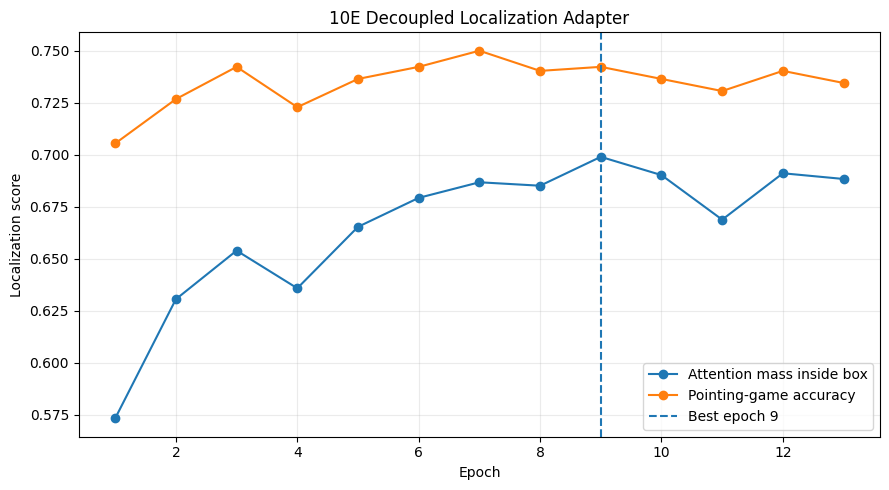

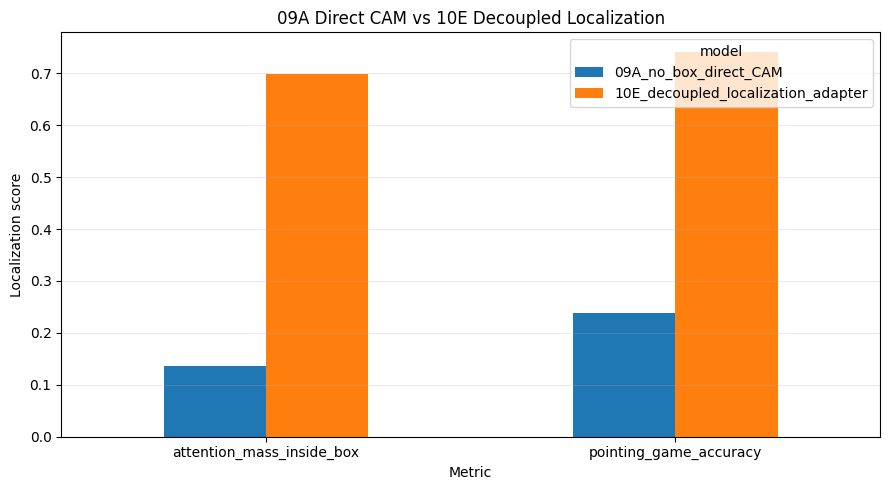

In [24]:
# ============================================================
# 27. Plots — no restricted X-rays
# ============================================================
history_df = pd.DataFrame(
    history
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    history_df["epoch"],
    history_df[
        "validation_attention_mass_inside_box"
    ],
    marker="o",
    label=
        "Attention mass inside box",
)

ax.plot(
    history_df["epoch"],
    history_df[
        "validation_pointing_game_accuracy"
    ],
    marker="o",
    label=
        "Pointing-game accuracy",
)

ax.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch {best_epoch}",
)

ax.set_xlabel(
    "Epoch"
)
ax.set_ylabel(
    "Localization score"
)
ax.set_title(
    "10E Decoupled Localization Adapter"
)
ax.grid(
    alpha=0.25
)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR
    / "localization_by_epoch.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()


plot_df = (
    comparison_df
    .set_index("model")[
        [
            "attention_mass_inside_box",
            "pointing_game_accuracy",
        ]
    ]
    .T
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

plot_df.plot(
    kind="bar",
    ax=ax,
)

ax.set_ylabel(
    "Localization score"
)
ax.set_xlabel(
    "Metric"
)
ax.set_title(
    "09A Direct CAM vs 10E Decoupled Localization"
)
ax.grid(
    axis="y",
    alpha=0.25,
)

plt.xticks(
    rotation=0
)
plt.tight_layout()

plt.savefig(
    FIG_DIR
    / "09A_vs_10E_localization.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()


In [25]:
# ============================================================
# 28. Save config + environment + human-readable summary
# ============================================================
peak_gpu_memory_gb = (
    torch.cuda.max_memory_allocated()
    / 1024**3
    if DEVICE.type == "cuda"
    else None
)

config = {
    "experiment_id":
        EXPERIMENT_ID,
    "stage":
        "Decoupled_Box_Supervised_Localization_Adapter",
    "base_experiment_id":
        BASELINE_EXPERIMENT_ID,
    "base_model_frozen":
        True,
    "feature_maps_detached":
        True,
    "base_model_parameter_hash_before":
        FROZEN_BASE_HASH_BEFORE,
    "base_model_parameter_hash_after":
        FROZEN_BASE_HASH_AFTER,
    "base_model_hash_unchanged":
        base_hash_unchanged,
    "max_disease_probability_difference":
        max_probability_difference,
    "base_pathology14_macro_AUPRC_before":
        baseline_ap,
    "base_pathology14_macro_AUPRC_after":
        post_base_ap,
    "adapter_architecture":
        "Conv1x1(2048->256) + GroupNorm + ReLU + Conv1x1(256->37)",
    "adapter_trainable_parameters":
        adapter_trainable,
    "local_finding_loss":
        "BinaryFocalLoss",
    "focal_gamma":
        FOCAL_GAMMA,
    "local_finding_loss_weight":
        LOCAL_FINDING_LOSS_WEIGHT,
    "box_loss_type":
        "negative_log_attention_mass_inside_box",
    "box_loss_weight":
        BOX_LOSS_WEIGHT,
    "optimizer":
        "AdamW",
    "localization_learning_rate":
        LOCALIZATION_LR,
    "localization_weight_decay":
        LOCALIZATION_WEIGHT_DECAY,
    "selection_metric":
        "validation_pair_weighted_attention_mass_inside_box",
    "image_size":
        IMAGE_SIZE,
    "box_mask_size":
        BOX_MASK_SIZE,
    "seed":
        SEED,
    "split_manifest_sha256":
        manifest_hash,
    "calibration_used":
        False,
    "official_test_used":
        False,
    "numeric_class_id_used":
        False,
    "bounding_boxes_used":
        True,
    "cg_am_fusion_used":
        False,
}

with open(
    OUTPUT_DIR
    / "config.json",
    "w",
) as f:
    json.dump(
        config,
        f,
        indent=2,
    )

environment_info = {
    "python":
        sys.version,
    "platform":
        platform.platform(),
    "torch":
        torch.__version__,
    "torchvision":
        torchvision.__version__,
    "pydicom":
        pydicom.__version__,
    "gpu_name":
        torch.cuda.get_device_name(
            0
        ),
    "peak_gpu_memory_gb":
        peak_gpu_memory_gb,
    "training_seconds":
        training_seconds,
    "training_minutes":
        training_seconds / 60,
    "best_epoch":
        int(best_epoch),
}

with open(
    OUTPUT_DIR
    / "environment_info.json",
    "w",
) as f:
    json.dump(
        environment_info,
        f,
        indent=2,
    )

summary_lines = [
    "Pedi-CGAM Lite — M08 Decoupled Localization Adapter",
    "=" * 72,
    "",
    "BASE CLASSIFIER",
    f"- Source: {BASELINE_EXPERIMENT_ID}",
    f"- 14-pathology Macro-AUPRC before adapter: {baseline_ap:.6f}",
    f"- 14-pathology Macro-AUPRC after adapter: {post_base_ap:.6f}",
    f"- Max disease-probability difference: {max_probability_difference:.12f}",
    f"- Base parameter hash unchanged: {base_hash_unchanged}",
    "",
    "09A DIRECT-CAM LOCALIZATION",
    (
        "- Attention mass inside boxes: "
        f"{baseline_loc['pair_weighted_attention_mass_inside_box']:.6f}"
    ),
    (
        "- Pointing-game accuracy: "
        f"{baseline_loc['pair_weighted_pointing_game_accuracy']:.6f}"
    ),
    "",
    "10E DECOUPLED LOCALIZATION",
    (
        "- Attention mass inside boxes: "
        f"{adapter_loc['pair_weighted_attention_mass_inside_box']:.6f}"
    ),
    (
        "- Pointing-game accuracy: "
        f"{adapter_loc['pair_weighted_pointing_game_accuracy']:.6f}"
    ),
    (
        "- Adapter finding Macro-AUPRC: "
        f"{final_adapter_stats['finding_summary']['actual36_macro_AUPRC']:.6f}"
    ),
    "",
    "LOCALIZATION CHANGE",
    (
        "- Attention-mass delta: "
        f"{adapter_loc['pair_weighted_attention_mass_inside_box'] - baseline_loc['pair_weighted_attention_mass_inside_box']:+.6f}"
    ),
    (
        "- Pointing-game delta: "
        f"{adapter_loc['pair_weighted_pointing_game_accuracy'] - baseline_loc['pair_weighted_pointing_game_accuracy']:+.6f}"
    ),
    "",
    "TRAINING",
    f"- Best epoch: {best_epoch}",
    f"- Adapter LR: {LOCALIZATION_LR:.1e}",
    f"- Box loss weight: {BOX_LOSS_WEIGHT}",
    f"- Trainable adapter parameters: {adapter_trainable:,}",
    f"- Training time: {training_seconds/60:.2f} minutes",
    "",
    "SAFETY",
    "- Calibration split used: NO",
    "- Official test used: NO",
    "- Base 09A classifier trainable: NO",
    "- Box gradients reach the base ResNet50: NO",
    "- CGAM fusion used: NO",
]

summary_text = "\n".join(
    summary_lines
)

print(summary_text)

with open(
    OUTPUT_DIR
    / "README_RESULTS.txt",
    "w",
) as f:
    f.write(
        summary_text
    )


Pedi-CGAM Lite — M08 Decoupled Localization Adapter

BASE CLASSIFIER
- Source: M01_DiseaseFinding_Multitask_Seed42
- 14-pathology Macro-AUPRC before adapter: 0.208439
- 14-pathology Macro-AUPRC after adapter: 0.208439
- Max disease-probability difference: 0.000000000000
- Base parameter hash unchanged: True

09A DIRECT-CAM LOCALIZATION
- Attention mass inside boxes: 0.135364
- Pointing-game accuracy: 0.238372

10E DECOUPLED LOCALIZATION
- Attention mass inside boxes: 0.698994
- Pointing-game accuracy: 0.742248
- Adapter finding Macro-AUPRC: 0.097913

LOCALIZATION CHANGE
- Attention-mass delta: +0.563630
- Pointing-game delta: +0.503876

TRAINING
- Best epoch: 9
- Adapter LR: 1.0e-04
- Box loss weight: 0.1
- Trainable adapter parameters: 534,309
- Training time: 11.31 minutes

SAFETY
- Calibration split used: NO
- Official test used: NO
- Base 09A classifier trainable: NO
- Box gradients reach the base ResNet50: NO
- CGAM fusion used: NO


In [26]:
# ============================================================
# 29. Final integrity gate
# ============================================================
checks = pd.DataFrame([
    {
        "check":
            "Frozen split SHA-256 verified",
        "passed":
            manifest_hash
            == EXPECTED_SPLIT_MANIFEST_SHA256,
    },
    {
        "check":
            "Train count = 5,408",
        "passed":
            len(train_df)
            == 5408,
    },
    {
        "check":
            "Validation count = 1,159",
        "passed":
            len(val_df)
            == 1159,
    },
    {
        "check":
            "09A checkpoint verified",
        "passed":
            m01_checkpoint.get(
                "experiment_id"
            )
            == BASELINE_EXPERIMENT_ID,
    },
    {
        "check":
            "09A disease metric reproduced",
        "passed":
            abs(
                baseline_ap
                - EXPECTED_M01_PATHOLOGY14_AUPRC
            )
            <= M01_REPRO_TOLERANCE,
    },
    {
        "check":
            "Base model has 0 trainable parameters",
        "passed":
            base_trainable
            == 0,
    },
    {
        "check":
            "Adapter has trainable parameters",
        "passed":
            adapter_trainable
            > 0,
    },
    {
        "check":
            "Feature maps detached for adapter training",
        "passed":
            True,
    },
    {
        "check":
            "Frozen base parameter hash unchanged",
        "passed":
            base_hash_unchanged,
    },
    {
        "check":
            "Base disease Macro-AUPRC unchanged",
        "passed":
            abs(
                post_base_ap
                - baseline_ap
            )
            <= 1e-10,
    },
    {
        "check":
            "Base disease probabilities unchanged",
        "passed":
            max_probability_difference
            <= 1e-7,
    },
    {
        "check":
            "Localization metric finite",
        "passed":
            np.isfinite(
                adapter_loc[
                    "pair_weighted_attention_mass_inside_box"
                ]
            ),
    },
    {
        "check":
            "Pointing-game metric finite",
        "passed":
            np.isfinite(
                adapter_loc[
                    "pair_weighted_pointing_game_accuracy"
                ]
            ),
    },
    {
        "check":
            "Best adapter checkpoint exists",
        "passed":
            BEST_ADAPTER_PATH.exists(),
    },
    {
        "check":
            "Calibration data not used",
        "passed":
            True,
    },
    {
        "check":
            "Official test not used",
        "passed":
            True,
    },
    {
        "check":
            "No preprocessing failures",
        "passed":
            len(
                cache_failures
            ) == 0,
    },
])

checks[
    "status"
] = checks[
    "passed"
].map({
    True:
        "PASS",
    False:
        "REVIEW",
})

display(checks)

checks.to_csv(
    OUTPUT_DIR
    / "final_integrity_status.csv",
    index=False,
)

FINAL_STATUS = (
    "PASS"
    if checks[
        "passed"
    ].all()
    else "REVIEW"
)

print(
    "\nM08 DECOUPLED LOCALIZATION FINAL STATUS:",
    FINAL_STATUS,
)

if FINAL_STATUS == "PASS":
    print(
        "✅ M08 DECOUPLED LOCALIZATION EXPERIMENT COMPLETED SUCCESSFULLY"
    )
else:
    print(
        "⚠️ REVIEW BEFORE MOVING TO CGAM"
    )


,check,passed,status
0,Frozen split SHA-256 verified,True,PASS
1,"Train count = 5,408",True,PASS
2,"Validation count = 1,159",True,PASS
3,09A checkpoint verified,True,PASS
4,09A disease metric reproduced,True,PASS
5,Base model has 0 trainable parameters,True,PASS
6,Adapter has trainable parameters,True,PASS
7,Feature maps detached for adapter training,True,PASS
8,Frozen base parameter hash unchanged,True,PASS
9,Base disease Macro-AUPRC unchanged,True,PASS



M08 DECOUPLED LOCALIZATION FINAL STATUS: PASS
✅ M08 DECOUPLED LOCALIZATION EXPERIMENT COMPLETED SUCCESSFULLY


# 30. Export rule

The ZIP will include:

- the trained localization adapter checkpoint;
- aggregate configuration;
- training history;
- aggregate localization metrics;
- per-finding localization metrics;
- adapter finding predictions;
- comparison tables;
- scientific plots.

The ZIP will **not** include:

- DICOM files;
- cached `.npy` images;
- raw box masks;
- raw bounding-box coordinate tables.


In [27]:
# ============================================================
# 31. Package complete M08 output
# ============================================================
ZIP_FILE = Path(
    "/kaggle/working/"
    "M08_DecoupledLocalizationAdapter_Seed42_All_Outputs.zip"
)

if ZIP_FILE.exists():
    ZIP_FILE.unlink()

source_files = sorted(
    p
    for p in OUTPUT_DIR.rglob("*")
    if p.is_file()
)

if not source_files:
    raise RuntimeError(
        "No M08 experiment outputs were found."
    )

blocked_extensions = {
    ".dcm",
    ".dicom",
    ".npy",
    ".npz",
}

for p in source_files:
    if (
        p.suffix.lower()
        in blocked_extensions
    ):
        raise RuntimeError(
            "STOP: restricted/raw file detected in output folder: "
            + str(p)
        )

with zipfile.ZipFile(
    ZIP_FILE,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6,
) as zf:
    for p in source_files:
        arcname = (
            Path(
                EXPERIMENT_ID
            )
            / p.relative_to(
                OUTPUT_DIR
            )
        )

        zf.write(
            p,
            arcname=str(
                arcname
            ),
        )

with zipfile.ZipFile(
    ZIP_FILE,
    "r",
) as zf:
    corrupt_entry = (
        zf.testzip()
    )
    archive_names = (
        zf.namelist()
    )

if corrupt_entry is not None:
    raise RuntimeError(
        "ZIP integrity failure: "
        + str(
            corrupt_entry
        )
    )

required_outputs = [
    "best_localization_adapter.pth",
    "config.json",
    "environment_info.json",
    "training_history.csv",
    "09A_vs_10E_comparison.csv",
    "localization_adapter_summary.csv",
    "localization_adapter_per_finding.csv",
    "localization_adapter_finding_metrics.csv",
    "localization_adapter_validation_predictions.csv",
    "final_integrity_status.csv",
    "README_RESULTS.txt",
]

missing_outputs = [
    name
    for name in required_outputs
    if not any(
        x.endswith(
            "/" + name
        )
        for x in archive_names
    )
]

if missing_outputs:
    raise RuntimeError(
        "ZIP is missing required outputs: "
        + str(
            missing_outputs
        )
    )

print(
    "✅ M08 COMPLETE OUTPUT ZIP CREATED"
)
print("File:", ZIP_FILE)
print(
    "ZIP size:",
    f"{ZIP_FILE.stat().st_size/(1024**2):.2f} MB",
)
print(
    "ZIP integrity: PASS"
)
print(
    "Raw DICOM/cache files included: NO"
)


✅ M08 COMPLETE OUTPUT ZIP CREATED
File: /kaggle/working/M08_DecoupledLocalizationAdapter_Seed42_All_Outputs.zip
ZIP size: 2.29 MB
ZIP integrity: PASS
Raw DICOM/cache files included: NO


## What to send back

After the run finishes, send:

`M08_DecoupledLocalizationAdapter_Seed42_All_Outputs.zip`

I will check:

- whether the 09A classifier remained exactly unchanged;
- attention mass inside boxes;
- pointing-game accuracy;
- adapter finding Macro-AUPRC;
- per-finding localization;
- convergence;
- integrity checks.

### Decision after 10E

If localization improves clearly while the 09A classifier stays unchanged, we will finally have:

1. a protected **global disease representation**, and
2. a separate **radiologist-supervised lesion representation**.

Those are the two inputs needed for the next step: **Pedi-CGAM Lite local/global fusion**.
